# Cloud Fraction Correlation

This notebook matches Planet cloud fraction with Landsat, Sentinel-2, and Aqua/Terra cloud fraction observations, then plots correlation scatterplots.

Edit the **Config** cell first. The notebook expects CSV files with columns like `time`, `cloud_fraction_1km`, and `satellite`. It also accepts common alternatives such as `date`, `datetime`, `cloud_fraction`, `cloud_cover`, `sensor`, or `platform`.

## Config

In [8]:
import os
from pathlib import Path

# BASE_PATH points to your OneDrive folder so the notebook can move across machines.
# If your OneDrive environment variable is missing, set BASE_PATH manually below.
BASE_PATH = Path(os.environ.get("OneDrive", ""))
if not BASE_PATH:
    raise EnvironmentError("OneDrive environment variable not found. Set BASE_PATH manually in this cell.")

# Same OneDrive data structure used by config.py.
DATA_ROOT = BASE_PATH / "classmaterials" / "BLab_research_data" / "Beth_research_data"

# Local project folder. This is where Planet output and notebook results live.
# If you clone/move this repo, change only this PROJECT_ROOT line.
PROJECT_ROOT = Path.cwd()

GAUGE_ID = "gauge1"
EXPORT_GAUGE_ID = GAUGE_ID.replace("_", "")  # external CSV names use gauge1, gauge2, ...
PLANET_RUN = "gauge1_planet_lookup_2026_06_15"

# Planet cloud-fraction output from this project.
PLANET_CSV = PROJECT_ROOT / "output" / "metadata" / PLANET_RUN / f"{EXPORT_GAUGE_ID}_cloud_fraction.csv"
# "F:\Research_PhD\Beth_research\output\metadata\gauge1_planet_lookup_2026_06_15\gauge1_cloud_fraction.csv"

# Other satellite cloud-fraction CSVs stored under OneDrive.
# Edit these filenames/folders to match your GEE exports.
# Set a path to None if you do not want to run that comparison yet.
AQUA_TERRA_DIR = DATA_ROOT / "aquaandterra_clouds"
SENSOR_FILES = {
    "aqua_terra": [
        AQUA_TERRA_DIR / f"{EXPORT_GAUGE_ID}_MOD_part1.csv",  # Terra MODIS
        AQUA_TERRA_DIR / f"{EXPORT_GAUGE_ID}_MOD_part2.csv",
        AQUA_TERRA_DIR / f"{EXPORT_GAUGE_ID}_MYD_part1.csv",  # Aqua MODIS
        AQUA_TERRA_DIR / f"{EXPORT_GAUGE_ID}_MYD_part2.csv",
    ],
    "terra": [
        AQUA_TERRA_DIR / f"{EXPORT_GAUGE_ID}_MOD_part1.csv",
        AQUA_TERRA_DIR / f"{EXPORT_GAUGE_ID}_MOD_part2.csv",
    ],
    "aqua": [
        AQUA_TERRA_DIR / f"{EXPORT_GAUGE_ID}_MYD_part1.csv",
        AQUA_TERRA_DIR / f"{EXPORT_GAUGE_ID}_MYD_part2.csv",
    ],
    "sentinel_2": DATA_ROOT / "Sentinel2_CloudCover_1km" / f"Sentinel2_CloudCover_1km_{EXPORT_GAUGE_ID}.csv",
    "landsat": DATA_ROOT / "Landsat_CloudFraction_1km" / f"Landsat_CloudFraction_1km_{EXPORT_GAUGE_ID}.csv",
}

# If Landsat/Sentinel-2/Aqua/Terra are all in one CSV, point each sensor above
# to that same file and use satellite_filters below to separate them.
SATELLITE_FILTERS = {
    "landsat": "landsat",
    "sentinel_2": "sentinel",  # use "sentinel-2" if that is exactly in your CSV
    "aqua_terra": "aqua|terra", # regex-like OR is supported
    "terra": "terra",
    "aqua": "aqua",
}

# Date range for the comparison. Use None to keep the full available period.
START_DATE = "2016-01-01"
END_DATE = "2026-03-08"

# 0 = exact same calendar date only.
# Use 1 or 2 if sparse satellite revisit dates need nearest Planet observations.
MATCH_WINDOW_DAYS = 0

# How to combine multiple images on the same day: "mean", "median", "min", or "max".
DAILY_STAT = "mean"

OUT_DIR = PROJECT_ROOT / "output" / "correlation"
OUT_DIR.mkdir(parents=True, exist_ok=True)

## Imports And Helper Functions

In [9]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

TIME_CANDIDATES = ("datetime", "acquired", "acquisition_time", "system:time_start", "date", "time", "system:index")
CLOUD_CANDIDATES = ("cloud_fraction_1km", "cloud_fraction", "cloud_cover", "cloud", "clouds", "mean_cloud_1km")
SATELLITE_CANDIDATES = ("satellite", "sensor", "satellite_name", "platform", "id")


def find_column(df, candidates, required=True):
    lower_to_original = {col.lower().strip(): col for col in df.columns}
    for candidate in candidates:
        key = candidate.lower().strip()
        if key in lower_to_original:
            return lower_to_original[key]
    if required:
        raise ValueError(f"Could not find one of {candidates}. Columns found: {list(df.columns)}")
    return None


def parse_system_index(series):
    text = series.astype(str).str.extract(r"(\d{8}T\d{6})", expand=False)
    return pd.to_datetime(text, format="%Y%m%dT%H%M%S", errors="coerce")


def parse_time_column(series):
    numeric_time = pd.to_numeric(series, errors="coerce")
    if numeric_time.notna().any():
        max_value = numeric_time.dropna().abs().max()
        if max_value > 1e11:
            return pd.to_datetime(numeric_time, unit="ms", errors="coerce")
        if max_value > 1e8:
            return pd.to_datetime(numeric_time, unit="s", errors="coerce")
    return pd.to_datetime(series, errors="coerce")


def parse_observation_time(df):
    lower_to_original = {col.lower().strip(): col for col in df.columns}

    # Some GEE exports have separate date and time columns.
    # Example Sentinel-2 rows: date=2025-01-02, time=16:13:34.
    if "date" in lower_to_original and "time" in lower_to_original:
        date_col = lower_to_original["date"]
        time_col = lower_to_original["time"]
        combined = df[date_col].astype(str).str.strip() + " " + df[time_col].astype(str).str.strip()
        parsed = pd.to_datetime(combined, errors="coerce")
        if parsed.notna().any():
            return parsed

    # Sentinel-2 system:index can look like 20250102T160559_20250102T161016_T17SPU.
    if "system:index" in lower_to_original:
        parsed = parse_system_index(df[lower_to_original["system:index"]])
        if parsed.notna().any():
            return parsed

    time_col = find_column(df, TIME_CANDIDATES)
    return parse_time_column(df[time_col])


def read_one_cloud_csv(csv_path):
    csv_path = Path(csv_path)
    if not csv_path.exists():
        raise FileNotFoundError(f"File does not exist: {csv_path}")
    df = pd.read_csv(csv_path)
    df["source_file"] = csv_path.name
    return df


def load_cloud_csv(csv_path, label, satellite_filter=None, start_date=None, end_date=None, daily_stat="mean"):
    if isinstance(csv_path, (list, tuple, set)):
        frames = [read_one_cloud_csv(path) for path in csv_path]
        df = pd.concat(frames, ignore_index=True)
    else:
        df = read_one_cloud_csv(csv_path)

    cloud_col = find_column(df, CLOUD_CANDIDATES)
    satellite_col = find_column(df, SATELLITE_CANDIDATES, required=False)

    clean = pd.DataFrame({
        "time": parse_observation_time(df),
        "cloud_fraction": pd.to_numeric(df[cloud_col], errors="coerce"),
    })

    # GEE exports often store cloud cover as a percentage from 0 to 100.
    # Planet output is already a fraction from 0 to 1.
    if clean["cloud_fraction"].dropna().gt(1).any():
        clean["cloud_fraction"] = clean["cloud_fraction"] / 100.0

    if satellite_col:
        clean["satellite"] = df[satellite_col].astype(str).str.lower().str.strip()
    else:
        clean["satellite"] = label.lower()

    # For Aqua/Terra files, infer the platform from MOD/MYD filenames when no
    # satellite column exists. MOD = Terra, MYD = Aqua.
    source_lower = df["source_file"].astype(str).str.lower()
    clean.loc[source_lower.str.contains("_mod_", na=False), "satellite"] = "terra"
    clean.loc[source_lower.str.contains("_myd_", na=False), "satellite"] = "aqua"

    clean = clean.dropna(subset=["time", "cloud_fraction"])
    clean = clean[(clean["cloud_fraction"] >= 0) & (clean["cloud_fraction"] <= 1)]

    if satellite_filter:
        clean = clean[clean["satellite"].str.contains(satellite_filter, case=False, na=False, regex=True)]

    if start_date:
        clean = clean[clean["time"].dt.date >= pd.to_datetime(start_date).date()]
    if end_date:
        clean = clean[clean["time"].dt.date <= pd.to_datetime(end_date).date()]

    clean["date"] = clean["time"].dt.floor("D")
    daily = (
        clean.groupby("date", as_index=False)
        .agg(cloud_fraction=("cloud_fraction", daily_stat), n_observations=("cloud_fraction", "size"))
        .sort_values("date")
    )
    daily = daily.rename(columns={
        "cloud_fraction": f"{label}_cloud_fraction",
        "n_observations": f"{label}_n",
    })
    return daily


def match_cloud_fraction(planet_daily, other_daily, tolerance_days=0):
    if tolerance_days == 0:
        matched = planet_daily.merge(other_daily, on="date", how="inner")
        matched["planet_date"] = matched["date"]
        matched["other_date"] = matched["date"]
        matched["date_difference_days"] = 0
        return matched

    planet_for_match = planet_daily.rename(columns={"date": "planet_date"})
    other_for_match = other_daily.rename(columns={"date": "other_date"})
    matched = pd.merge_asof(
        other_for_match.sort_values("other_date"),
        planet_for_match.sort_values("planet_date"),
        left_on="other_date",
        right_on="planet_date",
        direction="nearest",
        tolerance=pd.Timedelta(days=tolerance_days),
    ).dropna(subset=["planet_cloud_fraction"])
    matched["date_difference_days"] = (matched["other_date"] - matched["planet_date"]).dt.days
    return matched


def summarize_stats(matched, other_label):
    x = matched["planet_cloud_fraction"]
    y = matched[f"{other_label}_cloud_fraction"]
    diff = y - x
    return {
        "sensor": other_label,
        "n": int(len(matched)),
        "pearson_r": x.corr(y, method="pearson"),
        "spearman_r": x.corr(y, method="spearman"),
        "bias_other_minus_planet": diff.mean(),
        "rmse": np.sqrt(np.mean(diff**2)),
    }


def plot_correlation(matched, other_label, stats, out_png=None):
    x = matched["planet_cloud_fraction"].to_numpy()
    y = matched[f"{other_label}_cloud_fraction"].to_numpy()

    fig, ax = plt.subplots(figsize=(7, 6), dpi=150)
    ax.scatter(x, y, s=42, alpha=0.78, edgecolor="white", linewidth=0.6)
    ax.plot([0, 1], [0, 1], color="0.45", linestyle="--", linewidth=1.2, label="1:1")

    if len(matched) >= 2 and np.nanstd(x) > 0:
        slope, intercept = np.polyfit(x, y, 1)
        xx = np.linspace(0, 1, 100)
        ax.plot(xx, slope * xx + intercept, color="#bf3f3f", linewidth=1.6, label="fit")

    annotation = (
        f"n = {stats['n']}\n"
        f"Pearson r = {stats['pearson_r']:.3f}\n"
        f"Spearman r = {stats['spearman_r']:.3f}\n"
        f"Bias = {stats['bias_other_minus_planet']:.3f}\n"
        f"RMSE = {stats['rmse']:.3f}"
    )
    ax.text(0.04, 0.96, annotation, transform=ax.transAxes, ha="left", va="top", fontsize=10,
            bbox={"facecolor": "white", "edgecolor": "0.75", "alpha": 0.92})

    ax.set_title(f"Cloud Fraction Correlation: Planet vs {other_label.replace('_', ' ').title()}")
    ax.set_xlabel("Planet cloud fraction")
    ax.set_ylabel(f"{other_label.replace('_', ' ').title()} cloud fraction")
    ax.set_xlim(-0.03, 1.03)
    ax.set_ylim(-0.03, 1.03)
    ax.grid(True, color="0.9", linewidth=0.8)
    ax.legend(loc="lower right")
    fig.tight_layout()
    if out_png:
        fig.savefig(out_png)
    return fig, ax

## Load Planet Data

In [10]:
planet_raw = pd.read_csv(PLANET_CSV)
planet_times = parse_observation_time(planet_raw).dropna()

print(f"Planet CSV: {PLANET_CSV}")
print(f"Planet raw rows: {len(planet_raw)}")
if len(planet_times):
    print(f"Planet raw date range: {planet_times.min().date()} to {planet_times.max().date()}")
print(f"Notebook date filter: {START_DATE} to {END_DATE}")

planet_daily = load_cloud_csv(
    PLANET_CSV,
    label="planet",
    satellite_filter=None,
    start_date=START_DATE,
    end_date=END_DATE,
    daily_stat=DAILY_STAT,
)

print(f"Planet daily observations after filtering: {len(planet_daily)}")
if planet_daily.empty:
    print("No Planet rows remain after filtering. Check PLANET_RUN, START_DATE, and END_DATE in the Config cell.")

planet_daily.head()

Planet CSV: f:\Research_PhD\Beth_research\output\metadata\gauge1_planet_lookup_2026_06_15\gauge1_cloud_fraction.csv
Planet raw rows: 2873
Planet raw date range: 2016-08-08 to 2025-07-30
Notebook date filter: 2016-01-01 to 2026-03-08
Planet daily observations after filtering: 1654


,date,planet_cloud_fraction,planet_n
0,2016-08-08,0.00000,1
1,2016-08-14,0.08622,1
2,2016-08-29,1.00000,1
3,2016-09-03,0.00000,1
4,2016-10-11,0.00000,2


## Run All Sensor Correlations


Processing aqua_terra from 4 file(s):
  C:\Users\67651\OneDrive - Northeastern University\classmaterials\BLab_research_data\Beth_research_data\aquaandterra_clouds\gauge1_MOD_part1.csv
  C:\Users\67651\OneDrive - Northeastern University\classmaterials\BLab_research_data\Beth_research_data\aquaandterra_clouds\gauge1_MOD_part2.csv
  C:\Users\67651\OneDrive - Northeastern University\classmaterials\BLab_research_data\Beth_research_data\aquaandterra_clouds\gauge1_MYD_part1.csv
  C:\Users\67651\OneDrive - Northeastern University\classmaterials\BLab_research_data\Beth_research_data\aquaandterra_clouds\gauge1_MYD_part2.csv
aqua_terra daily observations after filtering: 2921


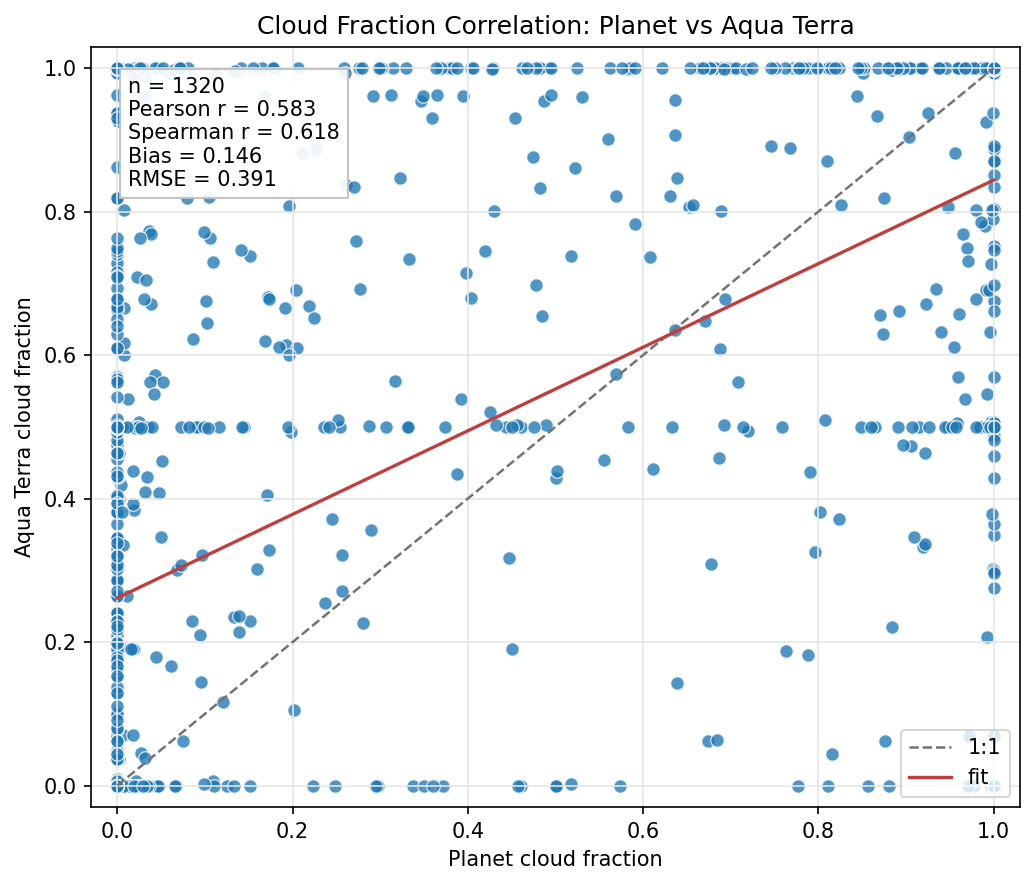

Matched observations: 1320
Pearson r: 0.583
Spearman r: 0.618
Bias (aqua_terra - Planet): 0.146
RMSE: 0.391
Saved matched CSV: f:\Research_PhD\Beth_research\output\correlation\planet_vs_aqua_terra_same_date_matched.csv
Saved figure: f:\Research_PhD\Beth_research\output\correlation\planet_vs_aqua_terra_same_date.png

Processing terra from 2 file(s):
  C:\Users\67651\OneDrive - Northeastern University\classmaterials\BLab_research_data\Beth_research_data\aquaandterra_clouds\gauge1_MOD_part1.csv
  C:\Users\67651\OneDrive - Northeastern University\classmaterials\BLab_research_data\Beth_research_data\aquaandterra_clouds\gauge1_MOD_part2.csv
terra daily observations after filtering: 2868


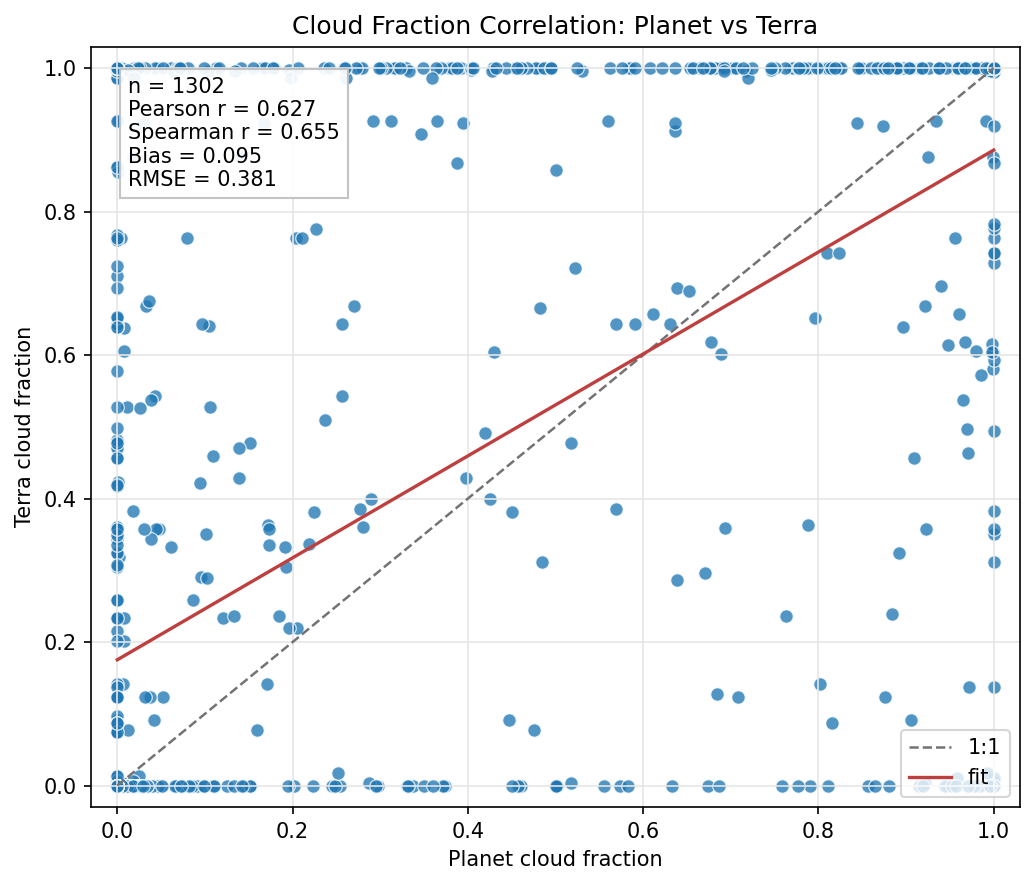

Matched observations: 1302
Pearson r: 0.627
Spearman r: 0.655
Bias (terra - Planet): 0.095
RMSE: 0.381
Saved matched CSV: f:\Research_PhD\Beth_research\output\correlation\planet_vs_terra_same_date_matched.csv
Saved figure: f:\Research_PhD\Beth_research\output\correlation\planet_vs_terra_same_date.png

Processing aqua from 2 file(s):
  C:\Users\67651\OneDrive - Northeastern University\classmaterials\BLab_research_data\Beth_research_data\aquaandterra_clouds\gauge1_MYD_part1.csv
  C:\Users\67651\OneDrive - Northeastern University\classmaterials\BLab_research_data\Beth_research_data\aquaandterra_clouds\gauge1_MYD_part2.csv
aqua daily observations after filtering: 2898


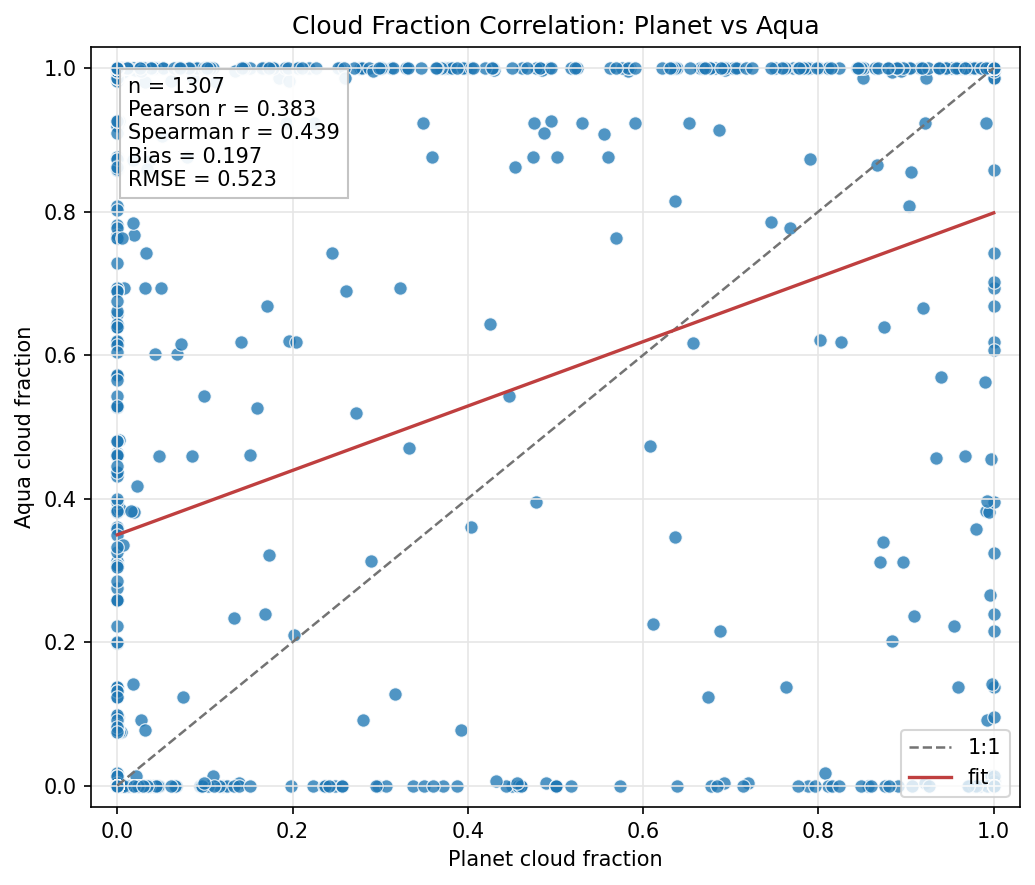

Matched observations: 1307
Pearson r: 0.383
Spearman r: 0.439
Bias (aqua - Planet): 0.197
RMSE: 0.523
Saved matched CSV: f:\Research_PhD\Beth_research\output\correlation\planet_vs_aqua_same_date_matched.csv
Saved figure: f:\Research_PhD\Beth_research\output\correlation\planet_vs_aqua_same_date.png

Processing sentinel_2 from 1 file(s):
  C:\Users\67651\OneDrive - Northeastern University\classmaterials\BLab_research_data\Beth_research_data\Sentinel2_CloudCover_1km\Sentinel2_CloudCover_1km_gauge1.csv
sentinel_2 daily observations after filtering: 484


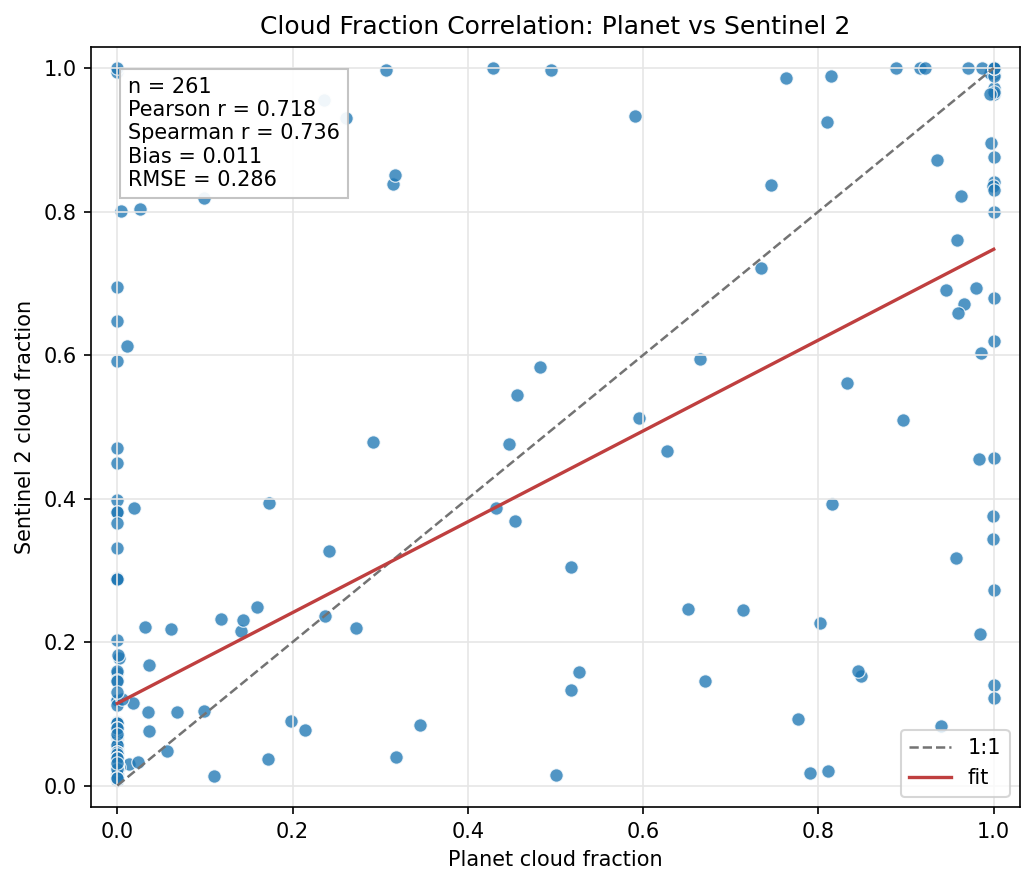

Matched observations: 261
Pearson r: 0.718
Spearman r: 0.736
Bias (sentinel_2 - Planet): 0.011
RMSE: 0.286
Saved matched CSV: f:\Research_PhD\Beth_research\output\correlation\planet_vs_sentinel_2_same_date_matched.csv
Saved figure: f:\Research_PhD\Beth_research\output\correlation\planet_vs_sentinel_2_same_date.png

Processing landsat from 1 file(s):
  C:\Users\67651\OneDrive - Northeastern University\classmaterials\BLab_research_data\Beth_research_data\Landsat_CloudFraction_1km\Landsat_CloudFraction_1km_gauge1.csv
landsat daily observations after filtering: 275


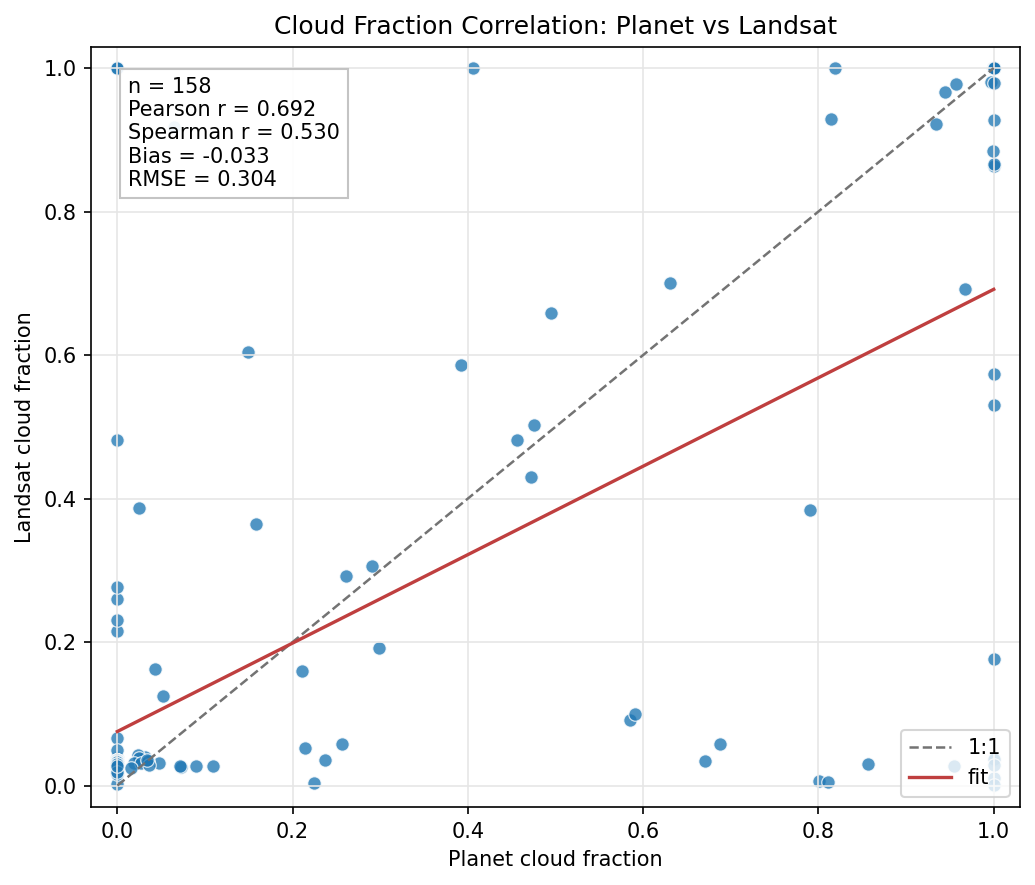

Matched observations: 158
Pearson r: 0.692
Spearman r: 0.530
Bias (landsat - Planet): -0.033
RMSE: 0.304
Saved matched CSV: f:\Research_PhD\Beth_research\output\correlation\planet_vs_landsat_same_date_matched.csv
Saved figure: f:\Research_PhD\Beth_research\output\correlation\planet_vs_landsat_same_date.png


In [11]:
all_stats = []
matched_tables = {}

for sensor_label, sensor_csv in SENSOR_FILES.items():
    if sensor_csv is None:
        print(f"Skipping {sensor_label}: path is None")
        continue

    sensor_paths = list(sensor_csv) if isinstance(sensor_csv, (list, tuple, set)) else [sensor_csv]
    sensor_paths = [Path(path) for path in sensor_paths]
    missing_paths = [path for path in sensor_paths if not path.exists()]
    if missing_paths:
        print(f"Skipping {sensor_label}: missing file(s)")
        for path in missing_paths:
            print(f"  {path}")
        continue

    print(f"\nProcessing {sensor_label} from {len(sensor_paths)} file(s):")
    for path in sensor_paths:
        print(f"  {path}")
    other_daily = load_cloud_csv(
        sensor_paths,
        label=sensor_label,
        satellite_filter=SATELLITE_FILTERS.get(sensor_label),
        start_date=START_DATE,
        end_date=END_DATE,
        daily_stat=DAILY_STAT,
    )
    print(f"{sensor_label} daily observations after filtering: {len(other_daily)}")

    matched = match_cloud_fraction(planet_daily, other_daily, tolerance_days=MATCH_WINDOW_DAYS)
    if matched.empty:
        print(f"No matched observations for {sensor_label}. Try MATCH_WINDOW_DAYS = 1 or 2.")
        continue

    stats = summarize_stats(matched, sensor_label)
    all_stats.append(stats)
    matched_tables[sensor_label] = matched

    match_name = "same_date" if MATCH_WINDOW_DAYS == 0 else f"nearest_{MATCH_WINDOW_DAYS}d"
    matched_csv = OUT_DIR / f"planet_vs_{sensor_label}_{match_name}_matched.csv"
    out_png = OUT_DIR / f"planet_vs_{sensor_label}_{match_name}.png"
    matched.to_csv(matched_csv, index=False)
    plot_correlation(matched, sensor_label, stats, out_png=out_png)
    plt.show()

    print(f"Matched observations: {stats['n']}")
    print(f"Pearson r: {stats['pearson_r']:.3f}")
    print(f"Spearman r: {stats['spearman_r']:.3f}")
    print(f"Bias ({sensor_label} - Planet): {stats['bias_other_minus_planet']:.3f}")
    print(f"RMSE: {stats['rmse']:.3f}")
    print(f"Saved matched CSV: {matched_csv}")
    print(f"Saved figure: {out_png}")

## Summary Table

In [12]:
summary = pd.DataFrame(all_stats)
if summary.empty:
    print("No correlations were produced. Check file paths, satellite filters, and date range.")
else:
    summary_path = OUT_DIR / "planet_sensor_correlation_summary.csv"
    summary.to_csv(summary_path, index=False)
    print(f"Saved summary: {summary_path}")
    display(summary)

Saved summary: f:\Research_PhD\Beth_research\output\correlation\planet_sensor_correlation_summary.csv


,sensor,n,pearson_r,spearman_r,bias_other_minus_planet,rmse
0,aqua_terra,1320,0.583280,0.618401,0.146262,0.391292
1,terra,1302,0.627118,0.654753,0.095429,0.381315
2,aqua,1307,0.382645,0.438620,0.196697,0.522607
3,sentinel_2,261,0.717724,0.735797,0.011128,0.285665
4,landsat,158,0.691897,0.529573,-0.033056,0.304042


## Save All Matched Tables

In [13]:
if not matched_tables:
    print("No matched tables to combine.")
else:
    combined_matched = pd.concat(
        [table.assign(sensor=sensor) for sensor, table in matched_tables.items()],
        ignore_index=True,
        sort=False,
    )
    combined_path = OUT_DIR / "planet_all_sensors_matched.csv"
    combined_matched.to_csv(combined_path, index=False)
    print(f"Saved combined matched table: {combined_path}")
    print(f"Rows: {len(combined_matched)}")
    display(combined_matched.head(20))

Saved combined matched table: f:\Research_PhD\Beth_research\output\correlation\planet_all_sensors_matched.csv
Rows: 4348


,date,planet_cloud_fraction,planet_n,aqua_terra_cloud_fraction,aqua_terra_n,planet_date,other_date,date_difference_days,sensor,terra_cloud_fraction,terra_n,aqua_cloud_fraction,aqua_n,sentinel_2_cloud_fraction,sentinel_2_n,landsat_cloud_fraction,landsat_n
0,2016-08-08,0.000000,1,0.9930,2.0,2016-08-08,2016-08-08,0,aqua_terra,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2016-08-14,0.086220,1,0.6220,2.0,2016-08-14,2016-08-14,0,aqua_terra,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2016-08-29,1.000000,1,1.0000,2.0,2016-08-29,2016-08-29,0,aqua_terra,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2016-09-03,0.000000,1,0.4310,2.0,2016-09-03,2016-09-03,0,aqua_terra,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2016-10-11,0.000000,2,0.0000,2.0,2016-10-11,2016-10-11,0,aqua_terra,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,2016-10-14,0.996029,1,0.0000,2.0,2016-10-14,2016-10-14,0,aqua_terra,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,2016-10-16,0.000000,2,0.0000,2.0,2016-10-16,2016-10-16,0,aqua_terra,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,2016-10-19,0.000000,1,0.0000,2.0,2016-10-19,2016-10-19,0,aqua_terra,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,2016-10-27,1.000000,1,0.4290,2.0,2016-10-27,2016-10-27,0,aqua_terra,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,2016-11-16,0.000000,1,0.0000,2.0,2016-11-16,2016-11-16,0,aqua_terra,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Inspect A Matched Table

Change `sensor_to_view` to `landsat`, `sentinel_2`, or `aqua_terra`.

In [14]:
sensor_to_view = "landsat"

if sensor_to_view in matched_tables:
    display(matched_tables[sensor_to_view].head(20))
else:
    print(f"No matched table available for {sensor_to_view}.")

,date,planet_cloud_fraction,planet_n,landsat_cloud_fraction,landsat_n,planet_date,other_date,date_difference_days
0,2017-03-22,1.000000,1,1.000000,1,2017-03-22,2017-03-22,0
1,2017-05-25,0.000000,1,0.260133,1,2017-05-25,2017-05-25,0
2,2017-06-10,0.000000,3,0.027526,1,2017-06-10,2017-06-10,0
3,2017-06-26,0.000000,3,0.029846,1,2017-06-26,2017-06-26,0
4,2017-07-12,0.391755,2,0.586283,1,2017-07-12,2017-07-12,0
5,2017-09-30,0.856013,1,0.029846,1,2017-09-30,2017-09-30,0
6,2017-12-03,0.032025,4,0.039121,1,2017-12-03,2017-12-03,0
7,2017-12-19,0.999915,2,0.176060,1,2017-12-19,2017-12-19,0
8,2018-01-04,0.000000,1,0.480953,1,2018-01-04,2018-01-04,0
9,2018-01-20,0.000000,1,0.036022,1,2018-01-20,2018-01-20,0
